# Carbon Impact Analysis

This notebook quantifies the carbon emissions avoided through renewable electricity generation in Germany.

Using historical solar and wind generation data, the analysis estimates the amount of carbon dioxide (CO₂) emissions displaced by renewable energy sources. The objective is to evaluate the environmental benefits of renewable electricity generation and provide sustainability-focused insights that complement the forecasting models developed in previous notebooks.

The analysis focuses on:

- Solar generation carbon impact
- Wind generation carbon impact
- Total renewable generation carbon impact
- Monthly and seasonal trends
- Renewable contributions to emissions reduction

## Methodology

Carbon emissions avoided are estimated using the following assumption:

- Renewable electricity generation displaces fossil-fuel-based electricity generation.
- A constant grid emission factor is applied to estimate avoided emissions.

The avoided emissions are calculated as:

CO₂ Avoided (kg) = Renewable Generation (MWh) × Emission Factor (kg CO₂/MWh)

For this project, an emission factor of:

**475 kg CO₂/MWh**

is assumed, representing a reasonable approximation of Germany's average grid carbon intensity during the study period.

This simplified methodology provides an estimate of the environmental benefits associated with renewable electricity generation.

The cleaned master dataset generated during the data preprocessing stage is used for carbon impact analysis. This ensures that missing values and data quality issues addressed during the cleaning workflow do not affect emissions calculations.

In [18]:
import pandas as pd
import numpy as np

# Load master dataset
df = pd.read_csv("../data/processed/master_clean.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50400, 21)


,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,...,wind_speed_ms,precipitation_mm,hour,day_of_week,month,year,is_weekend,quarter,week_of_year,season
0,2015-01-01 00:00:00+00:00,41151.0,71.0,8852.0,37248.0,27913.0,NaN,2015-01-01 00:00:00+00:00,0.96,94.4,...,8.50,0.0,0,3,1,2015,0,1,1,Winter
1,2015-01-01 01:00:00+00:00,40135.0,71.0,9054.0,37248.0,27913.0,NaN,2015-01-01 01:00:00+00:00,0.62,94.4,...,8.72,0.0,1,3,1,2015,0,1,1,Winter
2,2015-01-01 02:00:00+00:00,39106.0,71.0,9070.0,37248.0,27913.0,NaN,2015-01-01 02:00:00+00:00,0.44,94.0,...,8.84,0.0,2,3,1,2015,0,1,1,Winter
3,2015-01-01 03:00:00+00:00,38765.0,71.0,9163.0,37248.0,27913.0,NaN,2015-01-01 03:00:00+00:00,0.42,94.2,...,8.52,0.0,3,3,1,2015,0,1,1,Winter
4,2015-01-01 04:00:00+00:00,38941.0,71.0,9231.0,37248.0,27913.0,NaN,2015-01-01 04:00:00+00:00,0.18,94.2,...,9.34,0.0,4,3,1,2015,0,1,1,Winter


The dataset contains historical electricity generation and weather information for Germany. The renewable generation variables are used to estimate avoided carbon emissions resulting from solar and wind electricity production.

In [19]:
df.columns.tolist()

['utc_timestamp',
 'DE_load_actual_entsoe_transparency',
 'DE_solar_generation_actual',
 'DE_wind_generation_actual',
 'DE_solar_capacity',
 'DE_wind_capacity',
 'DE_LU_price_day_ahead',
 'time',
 'temperature_C',
 'humidity_pct',
 'cloud_cover_pct',
 'wind_speed_ms',
 'precipitation_mm',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'quarter',
 'week_of_year',
 'season']

In [20]:
df[
    [
        'DE_solar_generation_actual',
        'DE_wind_generation_actual'
    ]
].describe()

,DE_solar_generation_actual,DE_wind_generation_actual
count,50400.000000,50400.000000
mean,4556.721369,11554.100873
std,6936.231488,9072.601713
min,0.000000,135.000000
25%,0.000000,4509.750000
50%,164.000000,9018.500000
75%,7315.000000,16120.500000
max,32947.000000,46064.000000


## Estimating Avoided Carbon Emissions

The renewable generation variables in the dataset represent hourly electricity generation in Germany.

To estimate avoided carbon emissions, it is assumed that each megawatt-hour (MWh) of renewable electricity generation displaces electricity that would otherwise have been produced from fossil fuel sources.

An emission factor of:

**475 kg CO₂/MWh**

is applied throughout the analysis.

The following quantities are calculated:

- Solar CO₂ emissions avoided
- Wind CO₂ emissions avoided
- Total renewable CO₂ emissions avoided

These metrics provide an estimate of the environmental benefits associated with renewable electricity generation.

In [21]:
# Germany grid emission factor
EMISSION_FACTOR = 475  # kg CO2 per MWh

# Solar CO2 avoided
df['solar_co2_avoided_kg'] = (
    df['DE_solar_generation_actual']
    * EMISSION_FACTOR
)

# Wind CO2 avoided
df['wind_co2_avoided_kg'] = (
    df['DE_wind_generation_actual']
    * EMISSION_FACTOR
)

# Total CO2 avoided
df['total_co2_avoided_kg'] = (
    df['solar_co2_avoided_kg']
    + df['wind_co2_avoided_kg']
)

# Convert to tonnes
df['solar_co2_avoided_tonnes'] = (
    df['solar_co2_avoided_kg'] / 1000
)

df['wind_co2_avoided_tonnes'] = (
    df['wind_co2_avoided_kg'] / 1000
)

df['total_co2_avoided_tonnes'] = (
    df['total_co2_avoided_kg'] / 1000
)

df[
    [
        'solar_co2_avoided_tonnes',
        'wind_co2_avoided_tonnes',
        'total_co2_avoided_tonnes'
    ]
].head()

,solar_co2_avoided_tonnes,wind_co2_avoided_tonnes,total_co2_avoided_tonnes
0,33.725,4204.700,4238.425
1,33.725,4300.650,4334.375
2,33.725,4308.250,4341.975
3,33.725,4352.425,4386.150
4,33.725,4384.725,4418.450


## Total Carbon Impact

The total avoided carbon emissions are calculated by summing the hourly avoided emissions across the entire study period.

This provides an estimate of the cumulative environmental benefit delivered by solar generation, wind generation, and total renewable electricity generation in Germany.

In [22]:
total_solar_co2 = df['solar_co2_avoided_tonnes'].sum()

total_wind_co2 = df['wind_co2_avoided_tonnes'].sum()

total_renewable_co2 = df['total_co2_avoided_tonnes'].sum()

print(f"Total Solar CO₂ Avoided      : {total_solar_co2:,.0f} tonnes")

print(f"Total Wind CO₂ Avoided       : {total_wind_co2:,.0f} tonnes")

print(f"Total Renewable CO₂ Avoided  : {total_renewable_co2:,.0f} tonnes")

Total Solar CO₂ Avoided      : 109,087,910 tonnes
Total Wind CO₂ Avoided       : 276,605,175 tonnes
Total Renewable CO₂ Avoided  : 385,693,084 tonnes


## Interpretation of Total Carbon Impact

The cumulative avoided carbon emissions over the study period are summarized below.

| Source | CO₂ Avoided (tonnes) |
|----------|----------:|
| Solar Generation | 109,087,910 |
| Wind Generation | 276,605,175 |
| Total Renewable Generation | 385,693,084 |

The results demonstrate the substantial contribution of renewable electricity generation to emissions reduction in Germany.

Wind generation was responsible for the majority of avoided emissions, contributing approximately 72% of the total renewable carbon impact. Solar generation contributed approximately 28%.

These findings highlight the importance of wind power within Germany's renewable energy portfolio and explain why accurate wind generation forecasting is particularly valuable for assessing future emissions reductions.

Overall, renewable electricity generation avoided an estimated 385.7 million tonnes of CO₂ during the study period, illustrating the significant environmental benefits associated with the transition away from fossil-fuel-based electricity generation.

## Renewable Source Contributions

To better understand the environmental impact of Germany's renewable energy portfolio, the relative contributions of solar and wind generation to avoided carbon emissions are calculated.

This analysis reveals which renewable technology contributed most strongly to emissions reductions during the study period.

In [23]:
contribution_df = pd.DataFrame({
    "Source": ["Solar", "Wind"],
    "CO2 Avoided (tonnes)": [
        round(total_solar_co2),
        round(total_wind_co2)
    ],
    "Contribution (%)": [
        round(solar_pct, 2),
        round(wind_pct, 2)
    ]
})

contribution_df

,Source,CO2 Avoided (tonnes),Contribution (%)
0,Solar,109087910,28.28
1,Wind,276605175,71.72


## Interpretation of Renewable Source Contributions

The contribution analysis reveals that wind generation was the dominant source of avoided carbon emissions during the study period.

| Source | Contribution (%) |
|----------|----------:|
| Solar | 28.28 |
| Wind | 71.72 |

Wind generation accounted for approximately 72% of total avoided emissions, while solar generation contributed approximately 28%.

These findings are consistent with Germany's renewable electricity profile, where wind power represents a larger share of total renewable electricity generation than solar power. The results also explain why wind generation forecasting is particularly important for estimating future carbon impacts and evaluating progress toward decarbonization goals.

Overall, wind energy provided the majority of renewable carbon benefits during the study period, highlighting its critical role in Germany's energy transition.

## Monthly Carbon Impact Analysis

Renewable generation varies throughout the year due to seasonal changes in weather conditions, daylight availability, and wind resources.

To understand how carbon emissions reductions evolve over time, avoided emissions are aggregated on a monthly basis. This analysis helps identify seasonal patterns and periods during which renewable generation delivers the greatest environmental benefits.

In [24]:
# Ensure datetime format
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Create year-month column
df['year_month'] = df['utc_timestamp'].dt.to_period('M')

# Monthly aggregation
monthly_carbon = (
    df.groupby('year_month')[
        [
            'solar_co2_avoided_tonnes',
            'wind_co2_avoided_tonnes',
            'total_co2_avoided_tonnes'
        ]
    ]
    .sum()
    .reset_index()
)

monthly_carbon.head()

C:\Users\eguav\AppData\Local\Temp\ipykernel_23676\1564052680.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['utc_timestamp'].dt.to_period('M')


,year_month,solar_co2_avoided_tonnes,wind_co2_avoided_tonnes,total_co2_avoided_tonnes
0,2015-01,266089.775,4436608.300,4702698.075
1,2015-02,611996.175,2451876.850,3063873.025
2,2015-03,1357823.600,3304214.000,4662037.600
3,2015-04,2106807.400,2355816.650,4462624.050
4,2015-05,2095511.900,2511300.775,4606812.675


In [25]:
monthly_carbon.shape

(69, 4)

## Monthly Renewable Carbon Impact

The monthly avoided carbon emissions are visualized to identify long-term trends and seasonal variations in Germany's renewable energy contribution.

The analysis combines the contributions of both solar and wind generation and highlights periods during which renewable electricity generation delivered the greatest carbon reduction benefits.

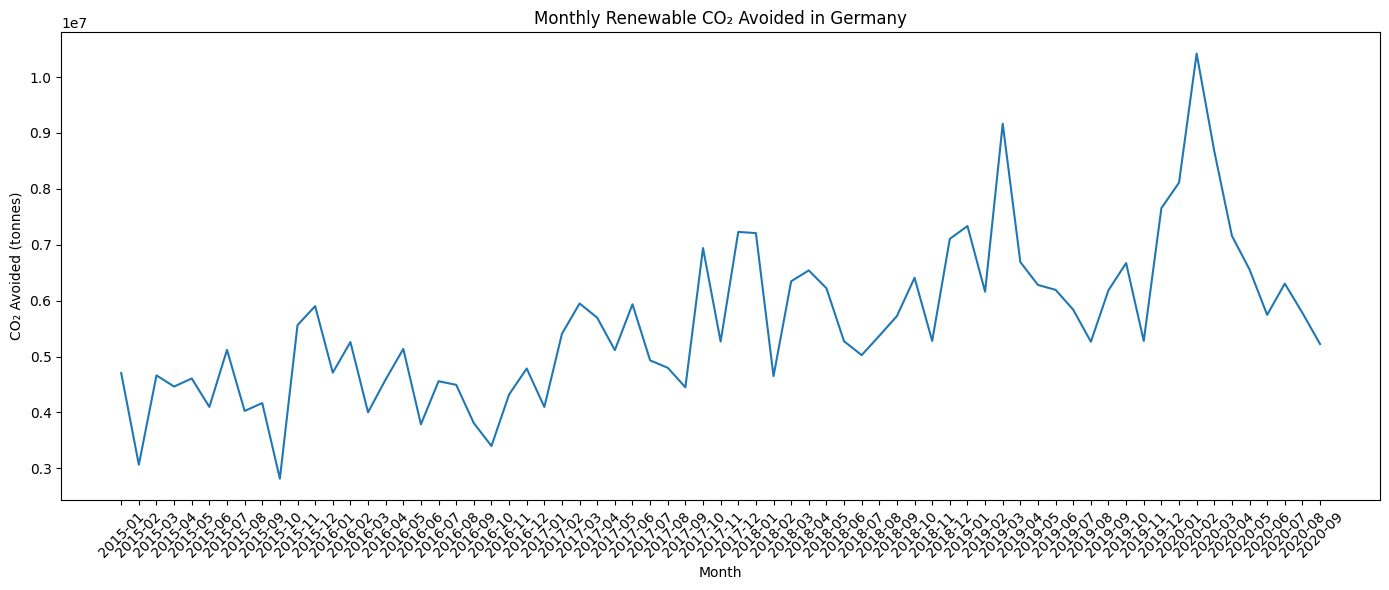

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_carbon['year_month'].astype(str),
    monthly_carbon['total_co2_avoided_tonnes']
)

plt.title('Monthly Renewable CO₂ Avoided in Germany')

plt.xlabel('Month')

plt.ylabel('CO₂ Avoided (tonnes)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Monthly Solar and Wind Carbon Impact Comparison

While total renewable generation provides an overview of avoided emissions, separating the contributions of solar and wind generation reveals how different renewable technologies contribute throughout the year.

This comparison highlights seasonal variations in renewable energy production and provides insight into the relative importance of solar and wind power within Germany's energy transition.

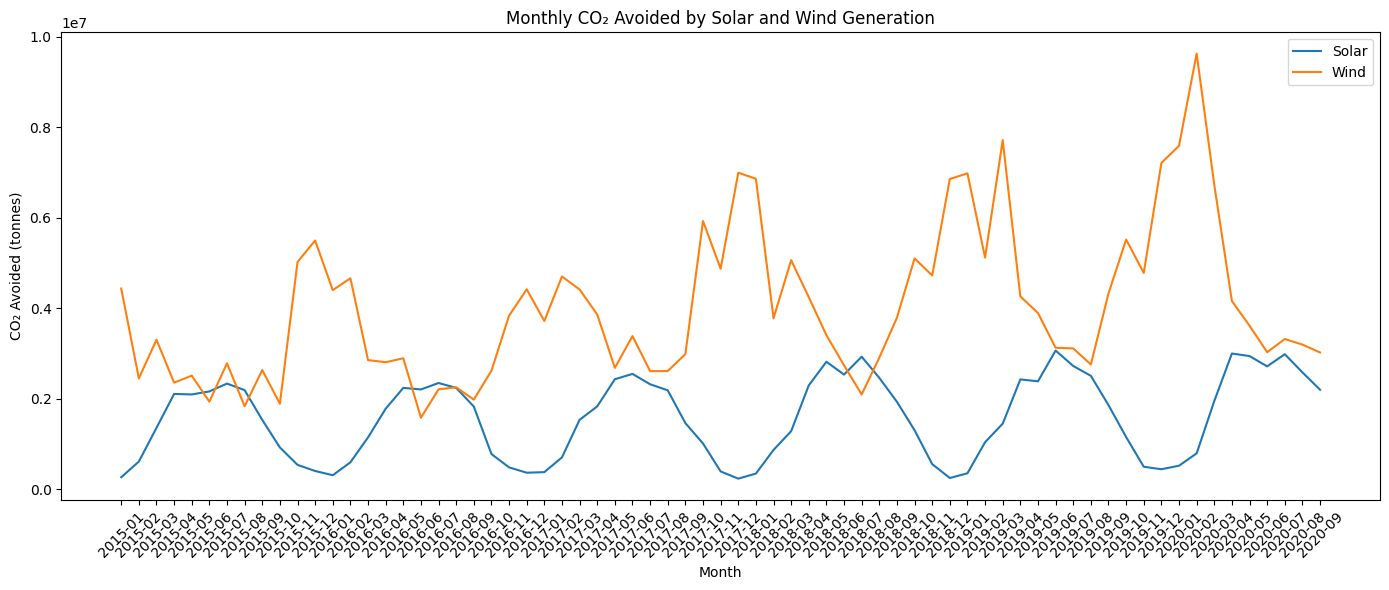

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_carbon['year_month'].astype(str),
    monthly_carbon['solar_co2_avoided_tonnes'],
    label='Solar'
)

plt.plot(
    monthly_carbon['year_month'].astype(str),
    monthly_carbon['wind_co2_avoided_tonnes'],
    label='Wind'
)

plt.title('Monthly CO₂ Avoided by Solar and Wind Generation')

plt.xlabel('Month')

plt.ylabel('CO₂ Avoided (tonnes)')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The comparison illustrates how solar and wind generation contribute differently to emissions reductions throughout the year.

Variations in solar carbon impact are largely driven by seasonal changes in solar irradiance and daylight duration, whereas wind carbon impact is influenced by seasonal wind patterns and atmospheric conditions.

Examining these trends separately provides a deeper understanding of the renewable generation sources responsible for avoided emissions in Germany.

## Interpretation of Monthly Solar and Wind Carbon Impacts

The monthly carbon impact profiles reveal clear seasonal differences between solar and wind generation.

Solar generation exhibits a pronounced seasonal cycle, with avoided emissions increasing during spring and summer months when solar irradiance and daylight hours are greatest. Carbon benefits decline during autumn and winter as solar resource availability decreases.

Wind generation displays a different seasonal pattern and generally contributes larger avoided emissions throughout the study period. Peak wind-related carbon reductions frequently occur during autumn and winter months, when wind resources are strongest.

The results demonstrate the complementary nature of solar and wind energy. Periods of reduced solar contribution are often offset by increased wind generation, helping to stabilize renewable electricity production and maintain emissions reductions throughout the year.

This complementarity highlights the importance of maintaining a diversified renewable energy portfolio to support long-term decarbonization objectives.

## Annual Carbon Impact Analysis

Annual aggregation provides a higher-level view of the environmental benefits delivered by renewable electricity generation.

By summing avoided emissions on a yearly basis, it becomes possible to evaluate long-term trends in renewable carbon impact and assess whether Germany's renewable energy transition is producing increasing emissions reductions over time.

In [29]:
# Create year column
df['year'] = pd.to_datetime(df['utc_timestamp']).dt.year

# Annual aggregation
annual_carbon = (
    df.groupby('year')[
        [
            'solar_co2_avoided_tonnes',
            'wind_co2_avoided_tonnes',
            'total_co2_avoided_tonnes'
        ]
    ]
    .sum()
    .reset_index()
)

# Round and remove scientific notation
annual_carbon[
    [
        'solar_co2_avoided_tonnes',
        'wind_co2_avoided_tonnes',
        'total_co2_avoided_tonnes'
    ]
] = annual_carbon[
    [
        'solar_co2_avoided_tonnes',
        'wind_co2_avoided_tonnes',
        'total_co2_avoided_tonnes'
    ]
].round(0).astype(int)

annual_carbon

,year,solar_co2_avoided_tonnes,wind_co2_avoided_tonnes,total_co2_avoided_tonnes
0,2015,16528749,36656836,53185585
1,2016,16327354,36519110,52846464
2,2017,17044415,48768717,65813131
3,2018,19585187,51568134,71153321
4,2019,19909505,58805887,78715392
5,2020,19692700,44286492,63979192


The annual carbon impact dataset summarizes avoided emissions from solar generation, wind generation, and total renewable generation for each year in the study period.

These yearly aggregates provide a clear view of how renewable energy contributions to emissions reduction have evolved over time.

## Annual Contributions of Solar and Wind Generation

To better understand the sources of annual emissions reductions, annual avoided emissions are separated into solar and wind components.

This visualization illustrates how each renewable technology contributed to Germany's carbon impact over time and highlights the dominant role of wind generation in avoided emissions.

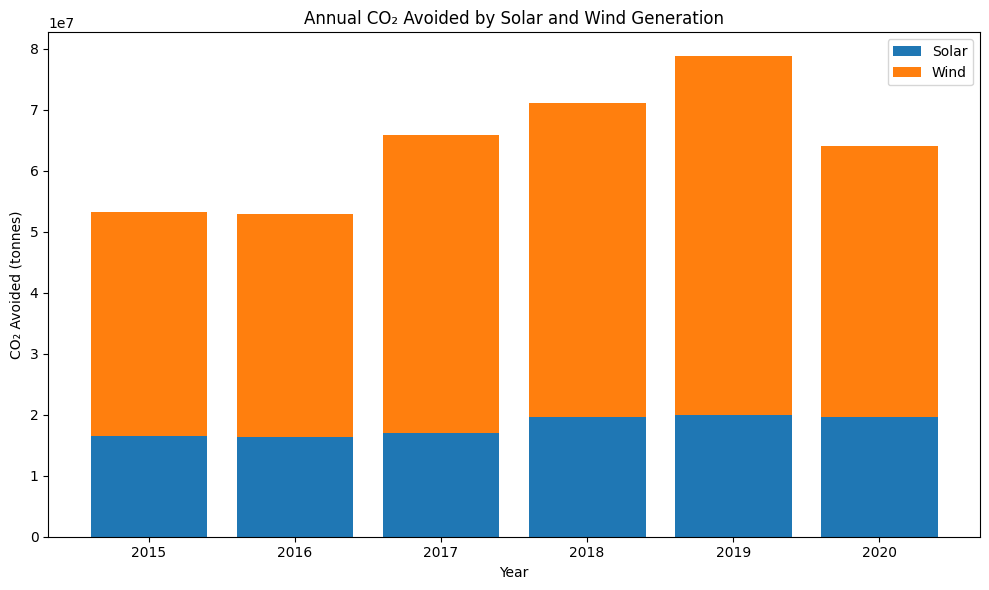

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    annual_carbon['year'].astype(str),
    annual_carbon['solar_co2_avoided_tonnes'],
    label='Solar'
)

plt.bar(
    annual_carbon['year'].astype(str),
    annual_carbon['wind_co2_avoided_tonnes'],
    bottom=annual_carbon['solar_co2_avoided_tonnes'],
    label='Wind'
)

plt.title('Annual CO₂ Avoided by Solar and Wind Generation')

plt.xlabel('Year')

plt.ylabel('CO₂ Avoided (tonnes)')

plt.legend()

plt.tight_layout()

plt.show()

## Interpretation of Annual Renewable Contributions

The annual contribution analysis confirms that wind generation was the primary source of avoided carbon emissions throughout the study period.

While solar generation contributed significantly to emissions reductions, wind generation consistently provided the larger share of avoided emissions in every year examined. The combined contribution of both technologies increased substantially between 2015 and 2019, reflecting the growing role of renewable electricity generation within Germany's energy system.

The apparent reduction observed in 2020 should be interpreted cautiously because the dataset only covers January to September 2020. Consequently, the reported value does not represent a complete year and is not directly comparable with previous annual totals.

Overall, the results highlight the complementary contributions of solar and wind power and demonstrate their collective importance in supporting Germany's decarbonization efforts.

## Seasonal Carbon Impact Analysis

Renewable electricity generation is strongly influenced by seasonal weather conditions.

To better understand the relationship between seasonality and avoided carbon emissions, the total carbon impact is aggregated by season. This analysis highlights the periods during which renewable electricity generation delivers the greatest environmental benefits and provides additional insight into the complementary behaviour of solar and wind resources.

In [32]:
# Create season column

df['month'] = pd.to_datetime(df['utc_timestamp']).dt.month

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df['season'] = df['month'].map(season_map)

# Aggregate by season

seasonal_carbon = (
    df.groupby('season')[
        [
            'solar_co2_avoided_tonnes',
            'wind_co2_avoided_tonnes',
            'total_co2_avoided_tonnes'
        ]
    ]
    .sum()
)

# Logical season order

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

seasonal_carbon = (
    seasonal_carbon
    .reindex(season_order)
    .round(0)
    .astype(int)
)

seasonal_carbon

,solar_co2_avoided_tonnes,wind_co2_avoided_tonnes,total_co2_avoided_tonnes
season,,,
Winter,8494500,95306873,103801373
Spring,37082168,70771081,107853250
Summer,45049113,47490380,92539493
Autumn,18462128,63036841,81498969


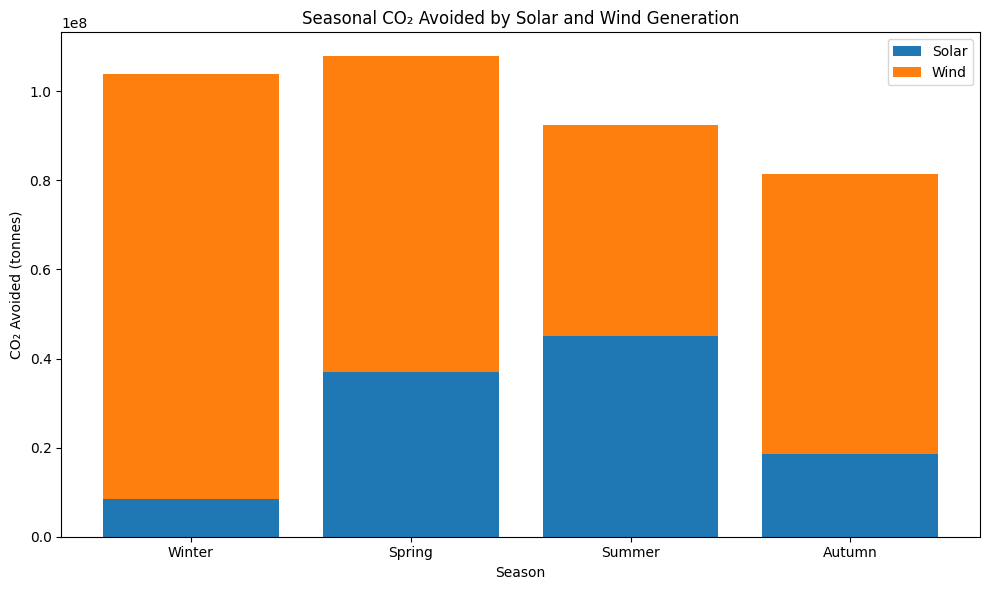

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    seasonal_carbon.index,
    seasonal_carbon['solar_co2_avoided_tonnes'],
    label='Solar'
)

plt.bar(
    seasonal_carbon.index,
    seasonal_carbon['wind_co2_avoided_tonnes'],
    bottom=seasonal_carbon['solar_co2_avoided_tonnes'],
    label='Wind'
)

plt.title('Seasonal CO₂ Avoided by Solar and Wind Generation')

plt.xlabel('Season')

plt.ylabel('CO₂ Avoided (tonnes)')

plt.legend()

plt.tight_layout()

plt.show()

## Interpretation of Seasonal Carbon Impacts

The seasonal analysis reveals clear differences in the contributions of solar and wind generation to avoided carbon emissions.

Solar generation contributes most strongly during spring and summer, when solar irradiance and daylight duration are highest. In contrast, wind generation provides the largest carbon benefits during autumn and winter, when wind resources are generally stronger.

The results demonstrate the complementary nature of Germany's renewable energy portfolio. Seasonal reductions in solar generation are partially offset by increased wind generation, helping to maintain renewable electricity production and carbon emissions reductions throughout the year.

This complementarity strengthens the resilience of the renewable energy system and supports year-round progress toward decarbonization objectives.

# Key Findings and Conclusions

This notebook quantified the carbon emissions avoided through renewable electricity generation in Germany between January 2015 and September 2020.

Key findings include:

- Renewable electricity generation avoided approximately **385.7 million tonnes of CO₂** during the study period.
- Wind generation contributed approximately **71.7%** of total avoided emissions.
- Solar generation contributed approximately **28.3%** of total avoided emissions.
- Annual renewable carbon benefits increased substantially between 2015 and 2019.
- Wind and solar generation exhibit complementary seasonal behaviour, supporting renewable electricity production throughout the year.
- The results highlight the critical role of renewable energy in reducing carbon emissions and advancing Germany's energy transition goals.

The forecasting models developed in previous notebooks provide a foundation for future estimation of renewable generation and associated carbon impacts, enabling the transition from historical analysis to forward-looking sustainability assessment.

## Saving Final Carbon Dataset

In [34]:
df.to_csv(
    "../data/processed/carbon_impact_dataset.csv",
    index=False
)

print("Carbon impact dataset saved.")

Carbon impact dataset saved.
